# HSIC noise-floor / oracle attention — visualisation

Auto-discovers every finished run under
`experiments/tests/hsic_noise_floor/results/<exp_name>_<jobid>/` and overlays
their training metrics. The same notebook will pick up new runs (e.g.
`noise_floor_hsic_norm`, `noise_floor_small_batch`) the moment they land —
no edits required.

**What we're comparing** (see `experiments/tests/hsic_noise_floor/README.md`):

| Run | Role |
|---|---|
| `noise_floor_hsic_bias`     | true oracle, biased HSIC — **lower bound** of `val_hsic_cross/_self` |
| `noise_floor_hsic_norm`     | true oracle, nHSIC — lower bound for the normalised estimator |
| `noise_floor_random_oracle` | wrong-DAG oracle (max-corrupted masks) — **upper bound** |
| `noise_floor_small_batch`   | true oracle, B=128 — probes `O(1/B)` HSIC bias |
| `noise_floor_small_capacity`| true oracle, d_model=16, linear head — capacity floor |

In [111]:
from __future__ import annotations

from pathlib import Path
import re
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../experiments/tests/hsic_noise_floor/results").resolve()
assert RESULTS_DIR.exists(), f"Results dir not found: {RESULTS_DIR}"

# Window (in epochs) over which converged-value summaries are computed.
CONVERGED_WINDOW = 50

# Stable color per logical experiment label so re-runs / new runs keep colours.
_PALETTE = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_LABEL_COLORS: dict[str, str] = {}

def color_for(label: str) -> str:
    if label not in _LABEL_COLORS:
        _LABEL_COLORS[label] = _PALETTE[len(_LABEL_COLORS) % len(_PALETTE)]
    return _LABEL_COLORS[label]

In [119]:
_JOBID_RE = re.compile(r"_(\d{5,})$")

def _strip_jobid(folder_name: str) -> str:
    """`noise_floor_hsic_bias_64807812` -> `noise_floor_hsic_bias`."""
    return _JOBID_RE.sub("", folder_name)

def _short_label(folder_name: str) -> str:
    base = _strip_jobid(folder_name)
    return base[len("noise_floor_"):] if base.startswith("noise_floor_") else base

def _latest_metrics_csv(run_dir: Path) -> Path | None:
    """Pick the metrics.csv from the highest-version_* under k_0/logs/csv."""
    csv_root = run_dir / "k_0" / "logs" / "csv"
    if not csv_root.exists():
        return None
    versions = sorted(
        (p for p in csv_root.glob("version_*") if p.is_dir()),
        key=lambda p: int(p.name.split("_")[-1]) if p.name.split("_")[-1].isdigit() else -1,
    )
    for v in reversed(versions):
        m = v / "metrics.csv"
        if m.exists():
            return m
    return None

def _read_run(run_dir: Path) -> dict | None:
    csv_path = _latest_metrics_csv(run_dir)
    if csv_path is None:
        return None
    raw = pd.read_csv(csv_path)
    if "epoch" not in raw.columns:
        return None
    # Lightning's CSVLogger writes interleaved train/val rows per epoch; collapse them.
    df = raw.groupby("epoch", as_index=False).first().sort_values("epoch").reset_index(drop=True)

    # Derived: sum of cross + self HSIC. Same scale per `hsic_mode`, so it makes sense
    # within each mode group as a global alignment-quality proxy.
    for sfx in ("train", "val"):
        cs, ss = f"{sfx}_hsic_cross", f"{sfx}_hsic_self"
        if cs in df.columns and ss in df.columns:
            df[f"{sfx}_hsic_sum"] = df[cs] + df[ss]

    cfg_path = run_dir / "config_single_causal_svfa.yaml"
    cfg = {}
    if cfg_path.exists():
        with open(cfg_path) as fh:
            cfg = yaml.safe_load(fh) or {}

    training = cfg.get("training", {}) or {}
    experiment = cfg.get("experiment", {}) or {}
    meta = {
        "folder": run_dir.name,
        "label": _short_label(run_dir.name),
        "hsic_mode": training.get("hsic_mode"),
        "hsic_kernel_source": training.get("hsic_kernel_source"),
        "hsic_adaptive_bandwidth": training.get("hsic_adaptive_bandwidth"),
        "hsic_sigma": training.get("hsic_sigma"),
        "corruption_seed": training.get("hard_masks_corruption_seed"),
        "cross_control_shd": training.get("cross_control_shd"),
        "self_control_shd": training.get("self_control_shd"),
        "use_oracle": training.get("use_oracle_attention"),
        "batch_size": experiment.get("batch_size", training.get("batch_size")),
        "d_model": experiment.get("d_model_set"),
        "max_epochs": experiment.get("max_epochs"),
        "csv_path": str(csv_path),
    }
    return {"df": df, "meta": meta}

runs: dict[str, dict] = {}
for run_dir in sorted(RESULTS_DIR.iterdir()):
    if not run_dir.is_dir():
        continue
    item = _read_run(run_dir)
    if item is None:
        continue
    runs[item["meta"]["label"]] = item

# Force a deterministic plot order: floor → ceiling → variants.
_ORDER_HINT = ["hsic_bias", "hsic_norm", "random_oracle", "small_batch", "small_capacity"]
_order_key = lambda lbl: (_ORDER_HINT.index(lbl) if lbl in _ORDER_HINT else len(_ORDER_HINT), lbl)
runs = {k: runs[k] for k in sorted(runs.keys(), key=_order_key)}

summary = pd.DataFrame(
    [
        {
            "label": item["meta"]["label"],
            "folder": item["meta"]["folder"],
            "epochs_logged": int(item["df"]["epoch"].max() + 1),
            "hsic_mode": item["meta"]["hsic_mode"],
            "corruption_seed": item["meta"]["corruption_seed"],
            "cross_shd": item["meta"]["cross_control_shd"],
            "self_shd": item["meta"]["self_control_shd"],
            "batch_size": item["meta"]["batch_size"],
            "d_model": item["meta"]["d_model"],
        }
        for item in runs.values()
    ]
).set_index("label")
print(f"Discovered {len(runs)} runs under {RESULTS_DIR}")
summary

Discovered 14 runs under C:\Users\ScipioneFrancesco\Documents\Projects\causaliT\experiments\tests\hsic_noise_floor\results


,folder,epochs_logged,hsic_mode,corruption_seed,cross_shd,self_shd,batch_size,d_model
label,,,,,,,,
hsic_bias,noise_floor_hsic_bias_64807812,501,biased,NaN,NaN,NaN,2048,48
hsic_norm,noise_floor_hsic_norm_64807799,263,normalized,NaN,NaN,NaN,2048,48
random_oracle,noise_floor_random_oracle_64807789,501,biased,NaN,NaN,NaN,2048,48
small_batch,noise_floor_small_batch_64807781,337,biased,NaN,NaN,NaN,128,48
small_capacity,noise_floor_small_capacity_64807779,501,biased,NaN,NaN,NaN,2048,16
anti_oracle_hsic_fixed_bw,anti_oracle_hsic_fixed_bw_64831575,481,biased,42.0,9999.0,9999.0,2048,48
anti_oracle_nhsic_fixed_bw,anti_oracle_nhsic_fixed_bw_64831564,132,normalized,42.0,9999.0,9999.0,2048,48
cross_only_anti,noise_floor_cross_only_anti_64821427,201,biased,42.0,9999.0,0.0,2048,48
hsic_norm_random_oracle,noise_floor_hsic_norm_random_oracle_64813818,233,normalized,NaN,NaN,NaN,2048,48


In [113]:
def legend_label(meta: dict) -> str:
    bits = [meta["label"]]
    if meta.get("hsic_mode"):
        bits.append(f"hsic={meta['hsic_mode']}")
    bw = meta.get("hsic_adaptive_bandwidth")
    if bw is False:
        bits.append(f"σ={meta.get('hsic_sigma', 1.0)} (fixed)")
    if meta.get("corruption_seed") not in (None, 0):
        c = meta.get("cross_control_shd") or 0
        s = meta.get("self_control_shd") or 0
        bits.append(f"corr=s{meta['corruption_seed']}/c{c}/s{s}")
    if meta.get("batch_size"):
        bits.append(f"B={meta['batch_size']}")
    if meta.get("d_model"):
        bits.append(f"d={meta['d_model']}")
    return "  |  ".join(bits)

def _bw_tag(meta: dict) -> str:
    bw = meta.get("hsic_adaptive_bandwidth")
    if bw is None:
        return "adaptive"   # default before the flag was logged
    return "adaptive" if bool(bw) else "fixed"

def split_runs_by_hsic_mode(runs_dict: dict) -> dict[str, dict]:
    """Split runs into {(hsic_mode, bw_tag): {label: item}}.

    Biased HSIC and nHSIC live on different numerical scales, so plotting
    them on the same axis is misleading. Likewise, fixed-bandwidth runs
    sit on a different numerical scale than adaptive-bandwidth runs (the
    median heuristic moves the kernel between the two), so they cannot be
    overlaid either. We render one figure per (mode, bandwidth) combination.

    Returned keys are human-readable strings like ``"biased / adaptive"`` so
    they can be used directly in figure titles.
    """
    groups: dict[str, dict] = {}
    for label, item in runs_dict.items():
        mode = item["meta"].get("hsic_mode") or "unknown"
        bw   = _bw_tag(item["meta"])
        key  = f"{mode} / {bw}"
        groups.setdefault(key, {})[label] = item
    # Stable order: (mode order) x (adaptive before fixed).
    _MODE_ORDER = ["biased", "normalized", "unknown"]
    _BW_ORDER   = ["adaptive", "fixed"]
    ordered = [f"{m} / {b}" for m in _MODE_ORDER for b in _BW_ORDER]
    return {k: groups[k] for k in ordered if k in groups}

def plot_metric(ax, metric: str, runs_dict: dict | None = None, *,
                ylabel: str | None = None, logy: bool = False) -> None:
    if runs_dict is None:
        runs_dict = runs
    plotted = 0
    for item in runs_dict.values():
        df = item["df"]
        if metric not in df.columns:
            continue
        s = df[["epoch", metric]].dropna()
        if s.empty:
            continue
        ax.plot(
            s["epoch"], s[metric],
            color=color_for(item["meta"]["label"]),
            label=legend_label(item["meta"]),
            linewidth=1.6,
        )
        plotted += 1
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel or metric)
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
    if logy:
        ax.set_yscale("log")
    if plotted == 0:
        ax.text(0.5, 0.5, f"no '{metric}' logged", ha="center", va="center",
                transform=ax.transAxes, alpha=0.5)

## 1 · HSIC curves (the headline)

`val_hsic_cross` is the noise floor we care about — every real (learned-alignment)
run should sit between `hsic_bias` (true oracle, lower bound) and `random_oracle`
(wrong-DAG oracle, upper bound).

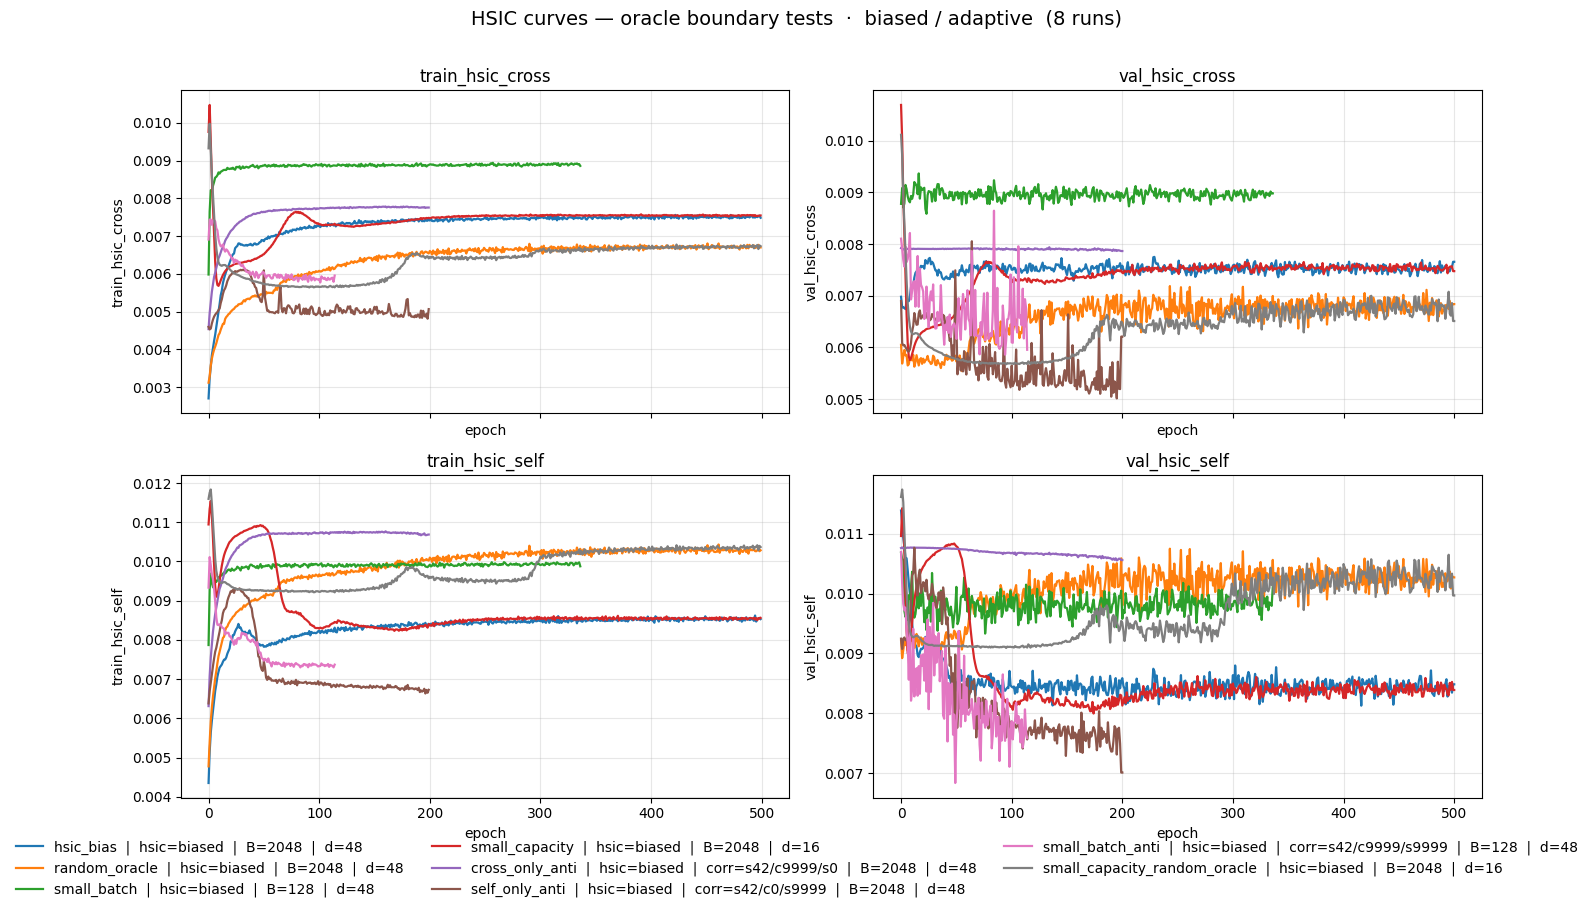

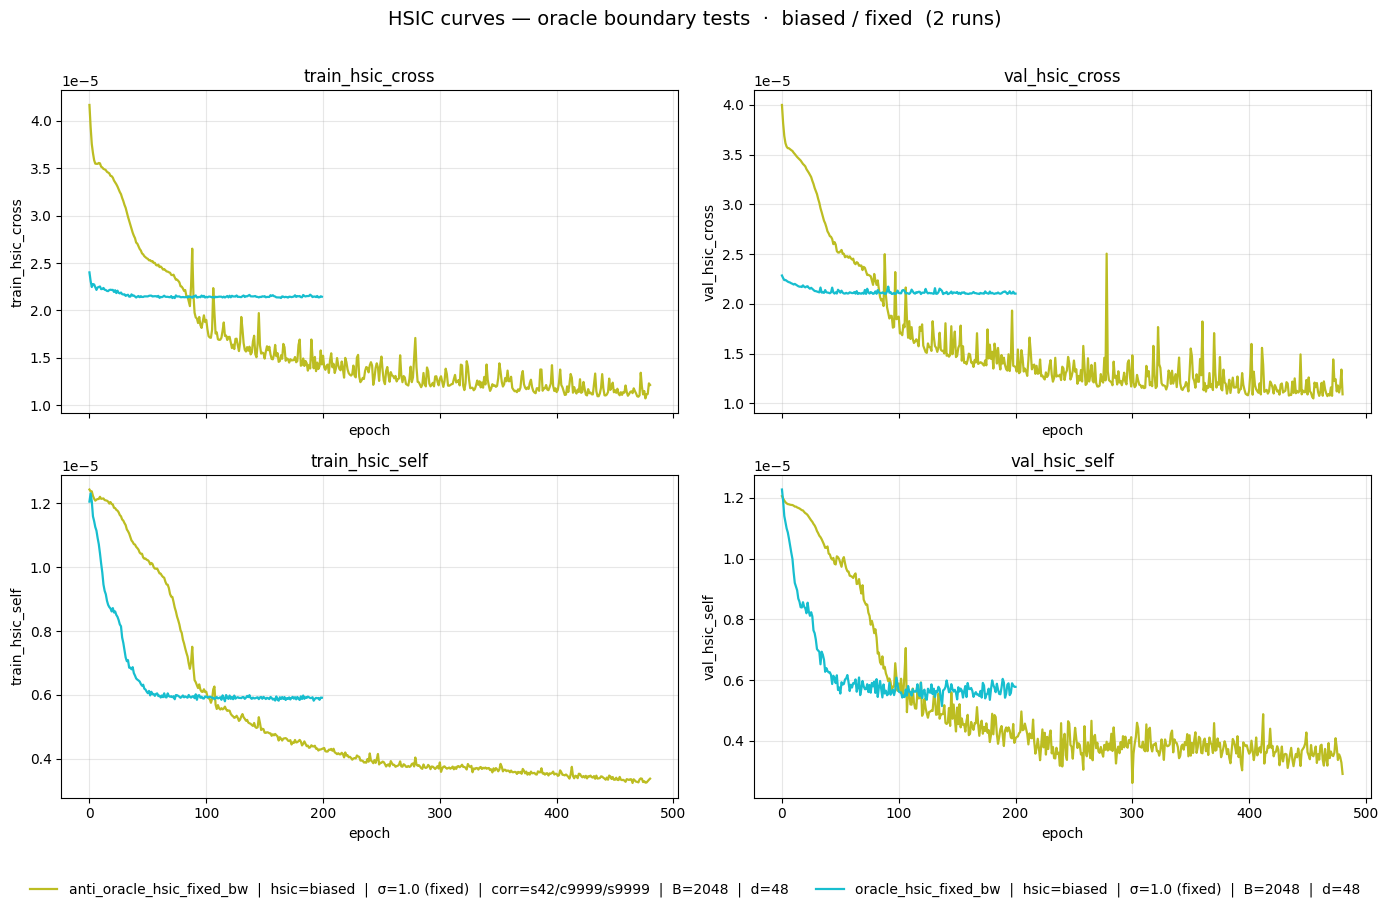

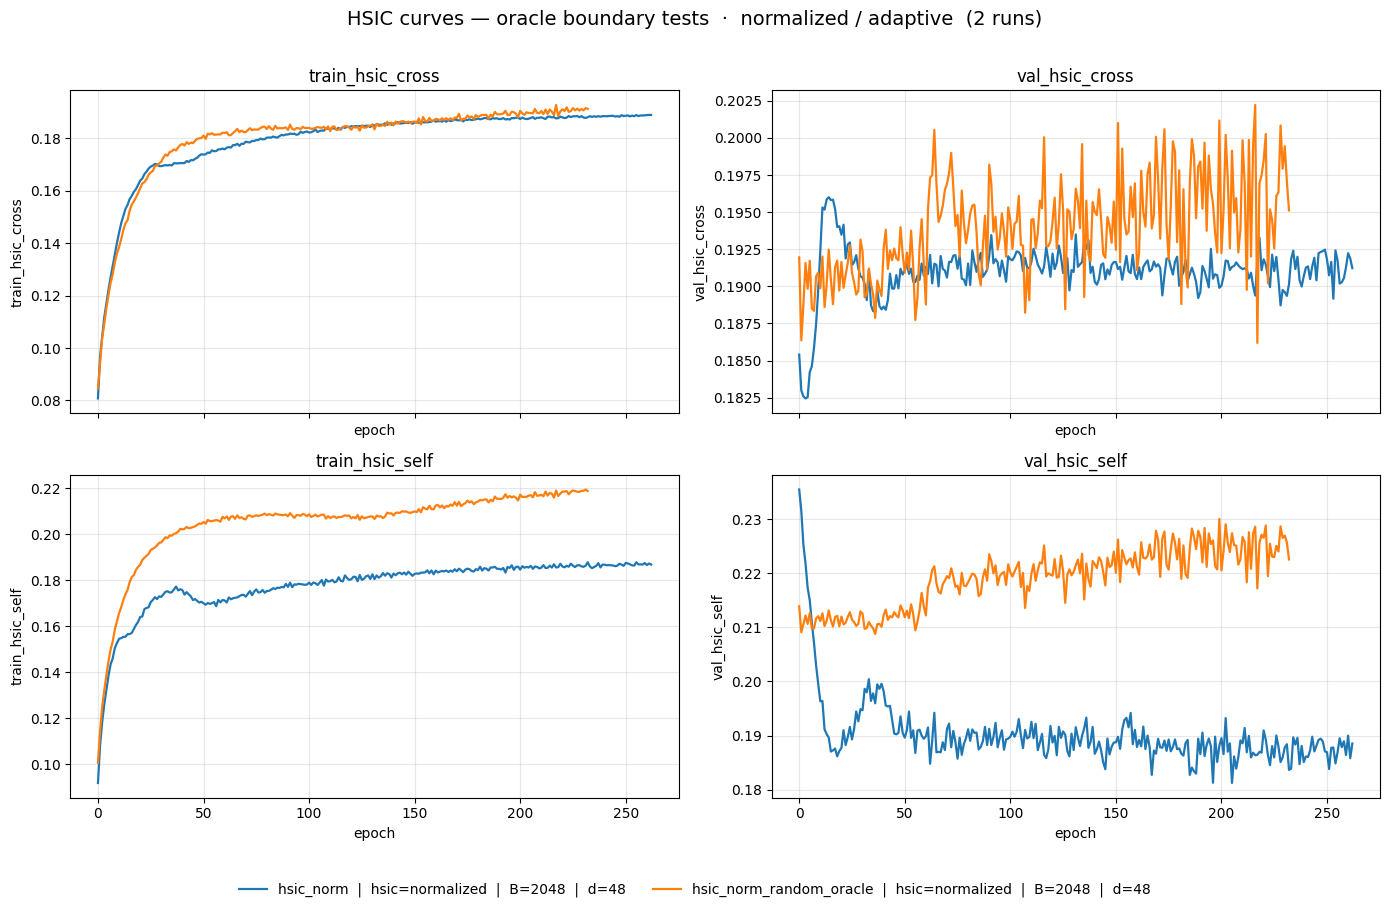

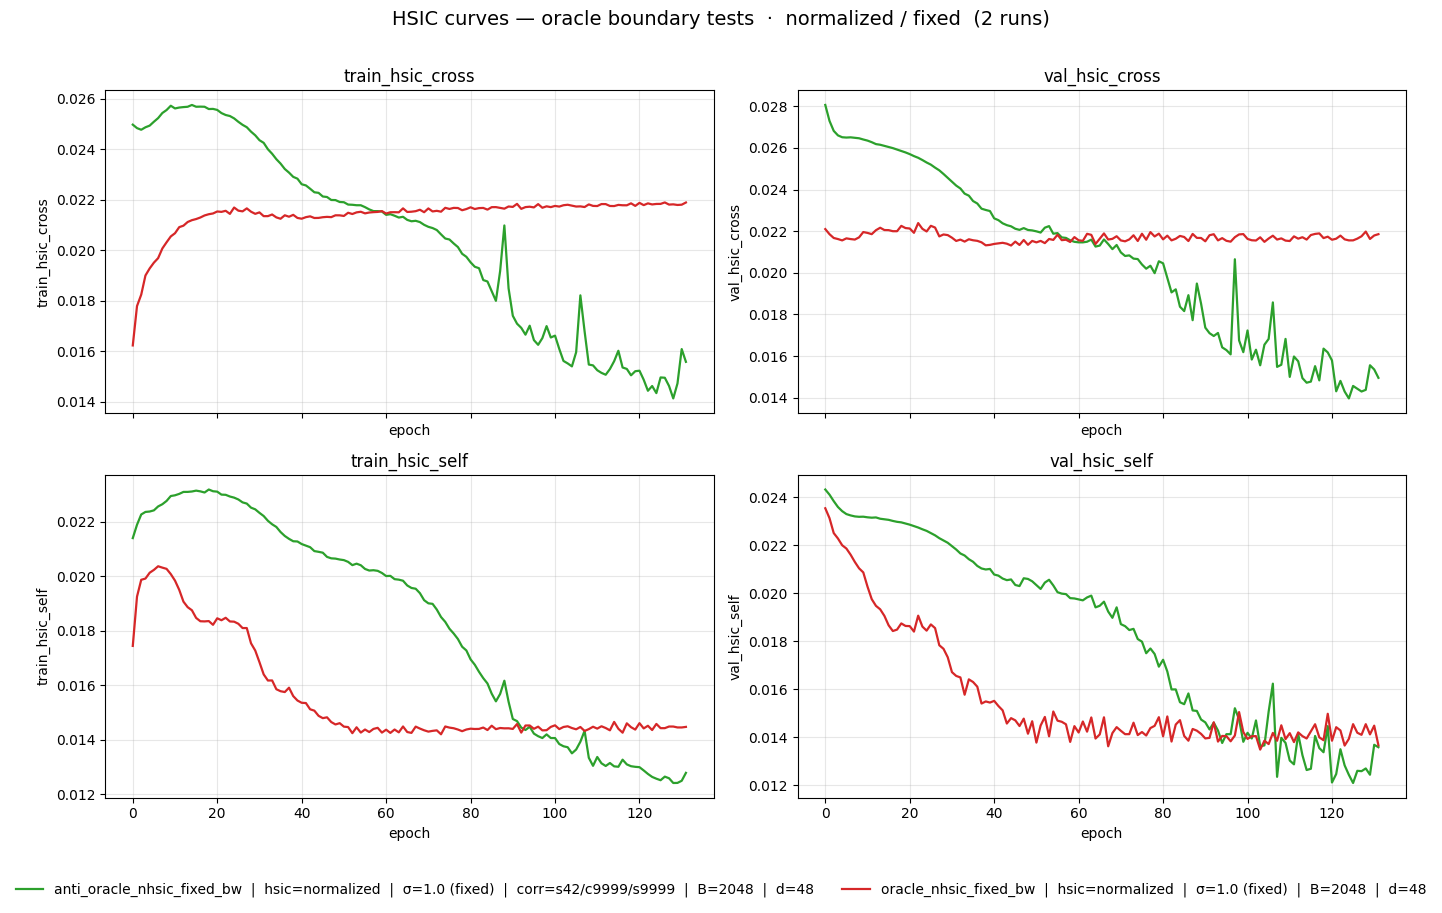

In [114]:
# Biased HSIC and nHSIC live on different scales — render one figure per mode.
for mode, runs_g in split_runs_by_hsic_mode(runs).items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    plot_metric(axes[0, 0], "train_hsic_cross", runs_g)
    plot_metric(axes[0, 1], "val_hsic_cross",   runs_g)
    plot_metric(axes[1, 0], "train_hsic_self",  runs_g)
    plot_metric(axes[1, 1], "val_hsic_self",    runs_g)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if not handles:
        for ax in axes.ravel():
            h, l = ax.get_legend_handles_labels()
            if h:
                handles, labels = h, l
                break
    fig.suptitle(f"HSIC curves — oracle boundary tests  ·  {mode}  ({len(runs_g)} runs)",
                 fontsize=14)
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02),
               ncol=min(3, max(1, len(runs_g))), frameon=False)
    fig.tight_layout(rect=(0, 0.04, 1, 0.97))
    plt.show()

### 1b · Sum HSIC_cross + HSIC_self  (global sanity check)

Pure sum of the two per-modality means — same scale within each `hsic_mode` group,
so it serves as a single global alignment-quality scalar. Expectation:

```
hsic_bias  <  cross_only_anti , self_only_anti  <  random_oracle
```

If `random_oracle` (joint corruption) sits above both isolated-anti runs, the
*joint-corruption → X̂ collapses → cross-pool HSIC drops* hypothesis is supported
and the sum is a valid global proxy.

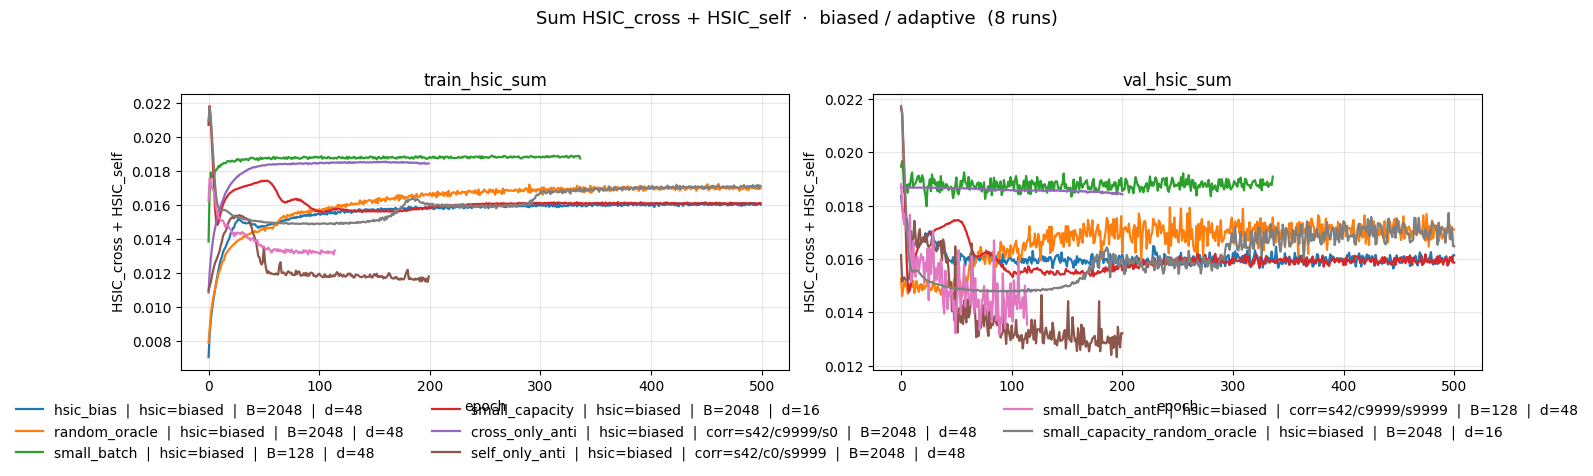

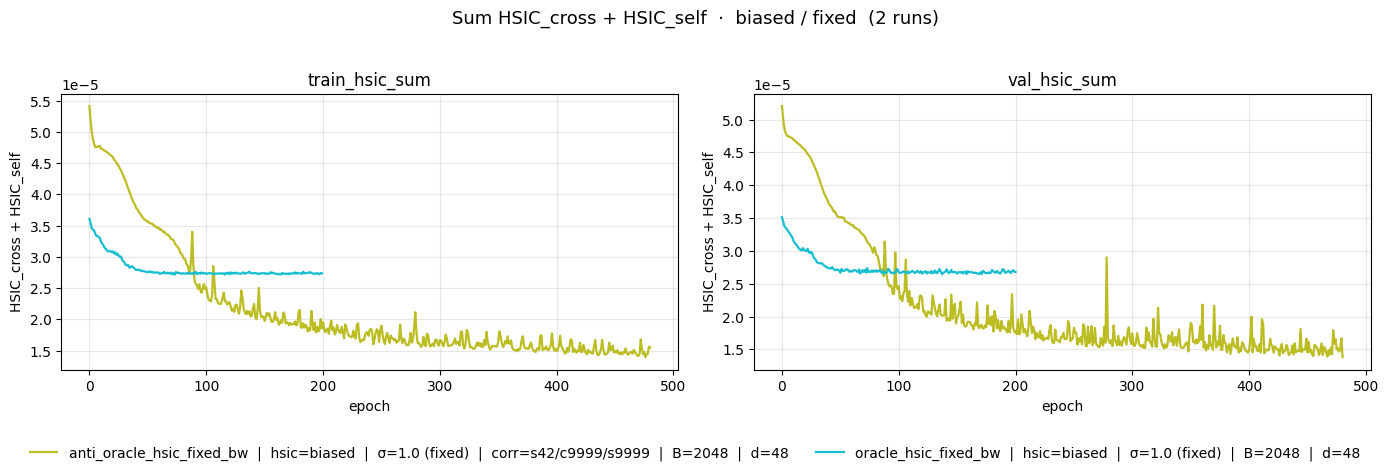

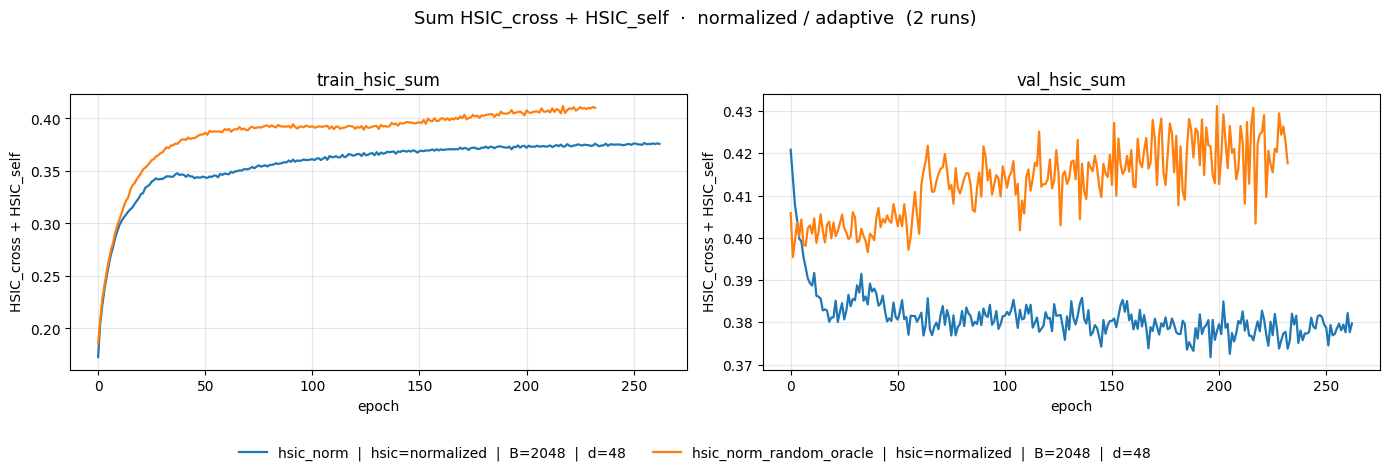

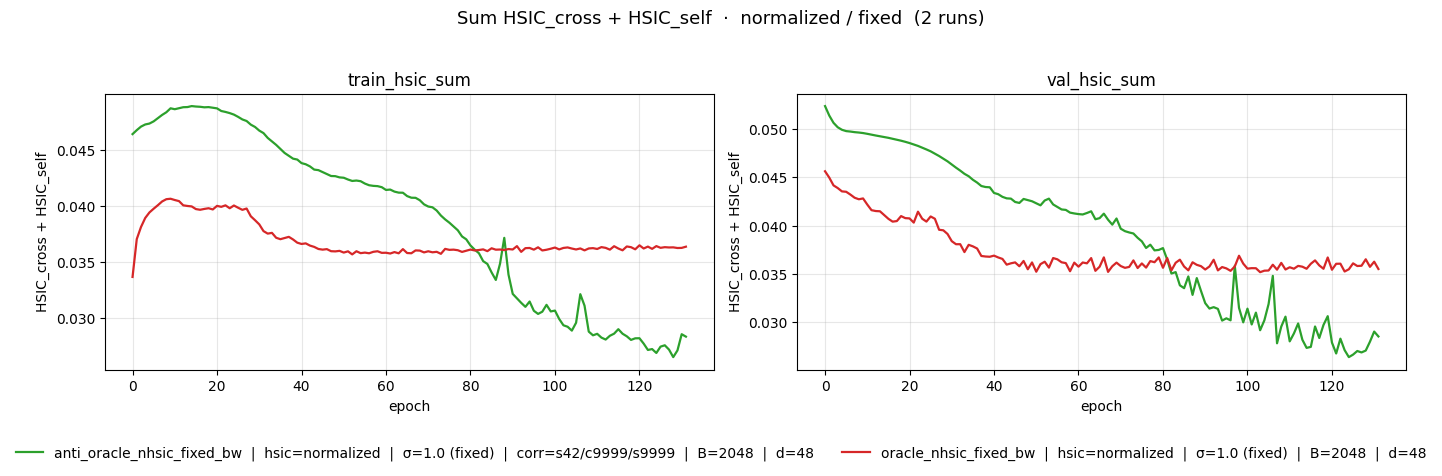

In [115]:
for mode, runs_g in split_runs_by_hsic_mode(runs).items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
    plot_metric(axes[0], "train_hsic_sum", runs_g, ylabel="HSIC_cross + HSIC_self")
    plot_metric(axes[1], "val_hsic_sum",   runs_g, ylabel="HSIC_cross + HSIC_self")
    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        for ax in axes.ravel():
            h, l = ax.get_legend_handles_labels()
            if h:
                handles, labels = h, l
                break
    fig.suptitle(f"Sum HSIC_cross + HSIC_self  ·  {mode}  ({len(runs_g)} runs)",
                 fontsize=13)
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
               ncol=min(3, max(1, len(runs_g))), frameon=False)
    fig.tight_layout(rect=(0, 0.05, 1, 0.95))
    plt.show()

## 2 · Reconstruction quality

Same alignment + same data, only the *mechanism* (embeddings + value path + FF +
MLP head) is learned. Smaller capacity / wrong DAG should show up here as worse
`val_x_rmse`.

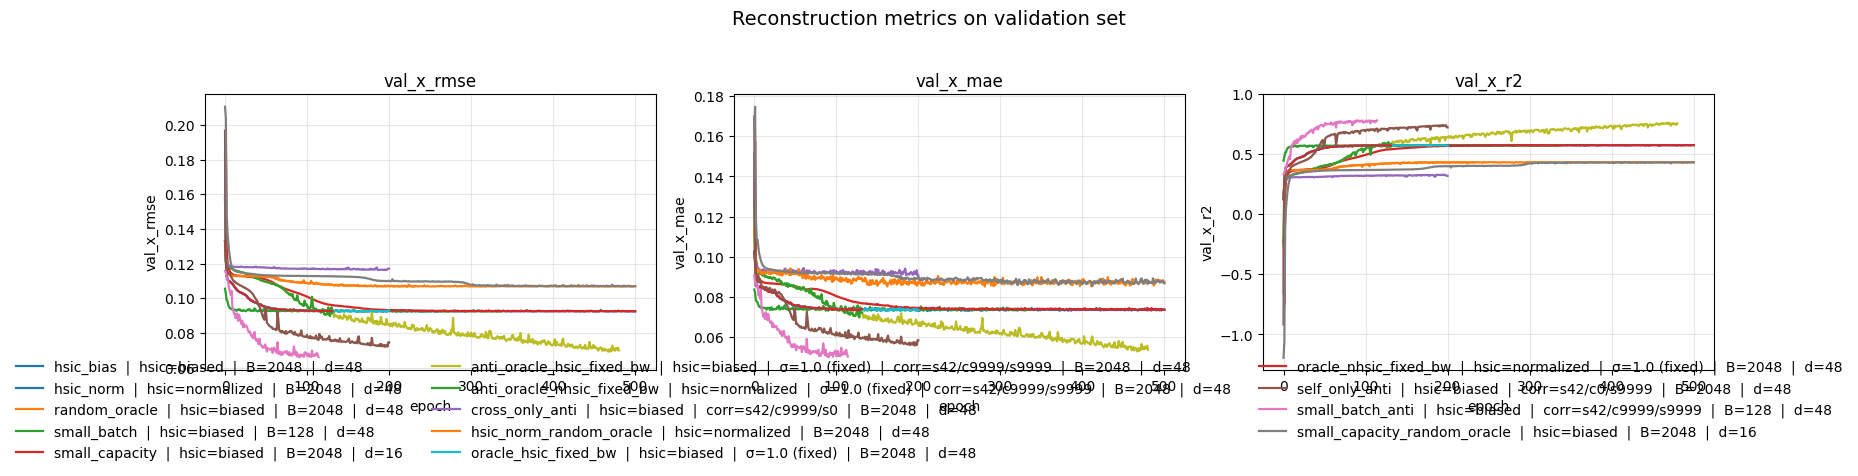

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
plot_metric(axes[0], "val_x_rmse")
plot_metric(axes[1], "val_x_mae")
plot_metric(axes[2], "val_x_r2")
axes[2].set_ylim(top=1.0)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=min(3, max(1, len(runs))), frameon=False)
fig.suptitle("Reconstruction metrics on validation set", fontsize=14)
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()

## 3 · Routed loss decomposition (sanity check)

Every λ on the structural side is `0.0` in these experiments, so
`train_loss_structural_routed` should sit at zero — confirming the gradient-routing
graph behaves like a recon-only run.

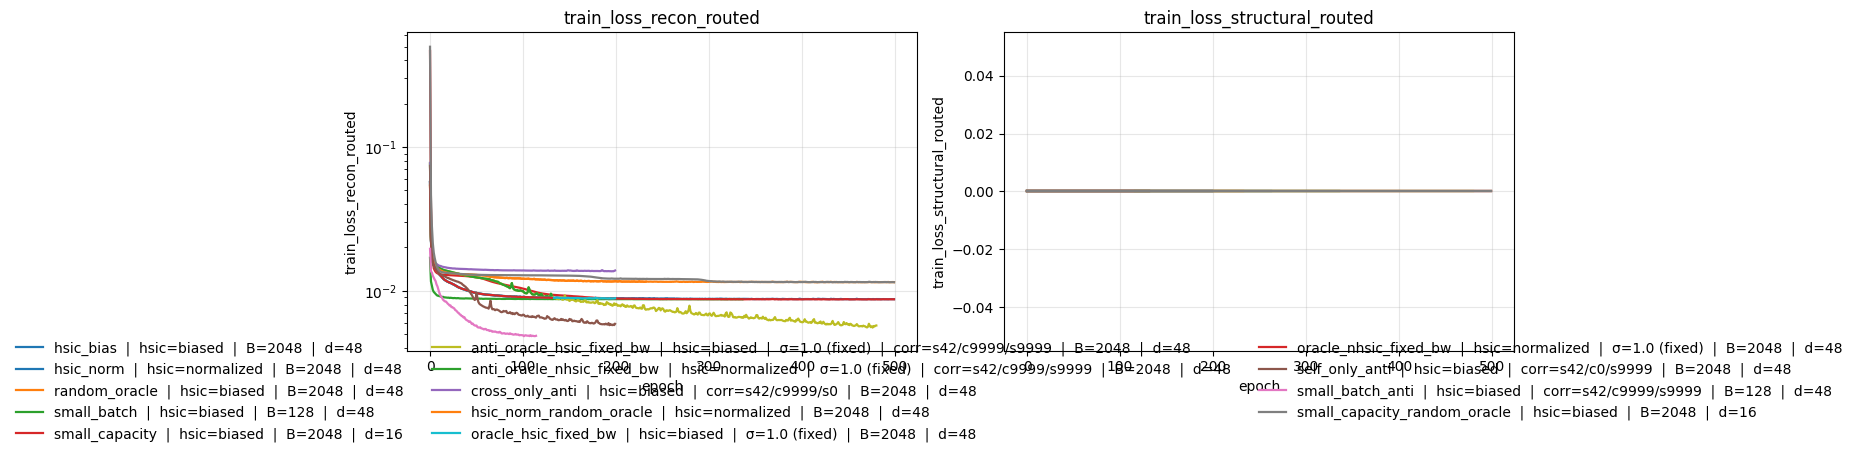

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
plot_metric(axes[0], "train_loss_recon_routed", logy=True)
plot_metric(axes[1], "train_loss_structural_routed")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=min(3, max(1, len(runs))), frameon=False)
fig.tight_layout(rect=(0, 0.05, 1, 0.97))
plt.show()

## 4 · Converged values — last 50 epochs

Mean over the final `CONVERGED_WINDOW` epochs of each run. This is the at-a-glance
comparison referenced by the README's *comparison rule*: any real-run
`val_hsic_cross` should lie between the floor (`hsic_bias`) and the ceiling
(`random_oracle`).


=== biased / adaptive   (8 runs) ===


,val_hsic_cross,val_hsic_self,val_hsic_sum,val_x_rmse,val_x_mae,val_x_r2
label,,,,,,
hsic_bias,0.0075,0.0084,0.0160,0.0925,0.0736,0.5759
random_oracle,0.0068,0.0102,0.0170,0.1069,0.0872,0.4339
small_batch,0.0090,0.0099,0.0188,0.0926,0.0737,0.5739
small_capacity,0.0075,0.0084,0.0159,0.0926,0.0737,0.5758
cross_only_anti,0.0079,0.0106,0.0185,0.1167,0.0919,0.3256
self_only_anti,0.0054,0.0076,0.0130,0.0738,0.0576,0.7303
small_batch_anti,0.0065,0.0078,0.0144,0.0678,0.0520,0.7715
small_capacity_random_oracle,0.0068,0.0103,0.0170,0.1071,0.0874,0.4325


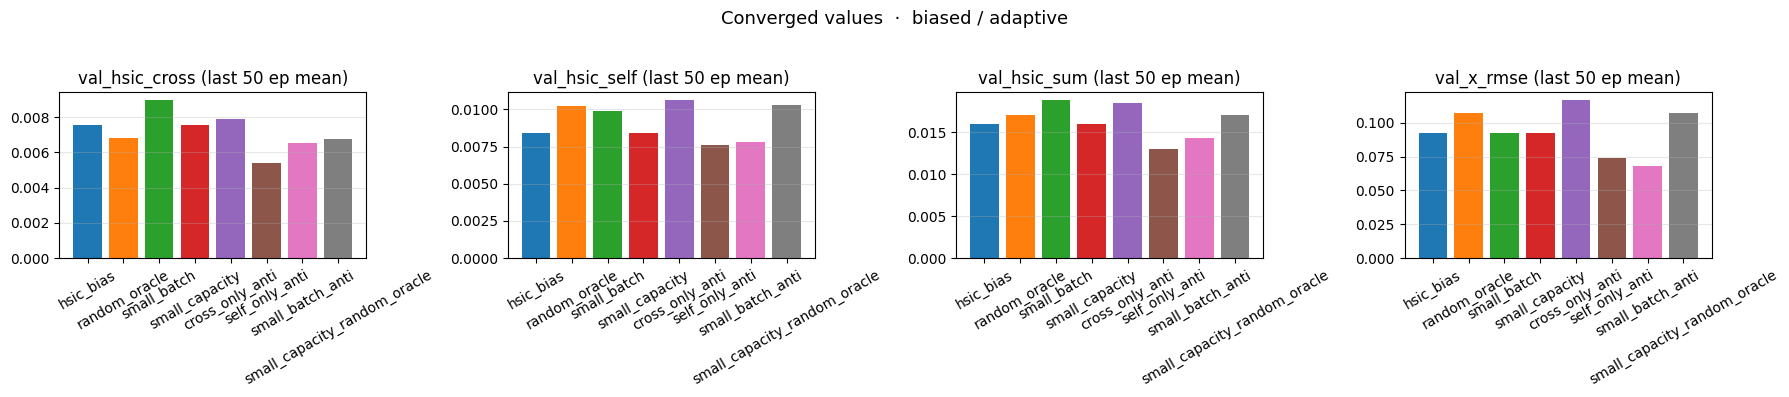


=== biased / fixed   (2 runs) ===


,val_hsic_cross,val_hsic_self,val_hsic_sum,val_x_rmse,val_x_mae,val_x_r2
label,,,,,,
anti_oracle_hsic_fixed_bw,0.0000,0.0000,0.0000,0.0711,0.0550,0.7494
oracle_hsic_fixed_bw,0.0000,0.0000,0.0000,0.0926,0.0736,0.5750


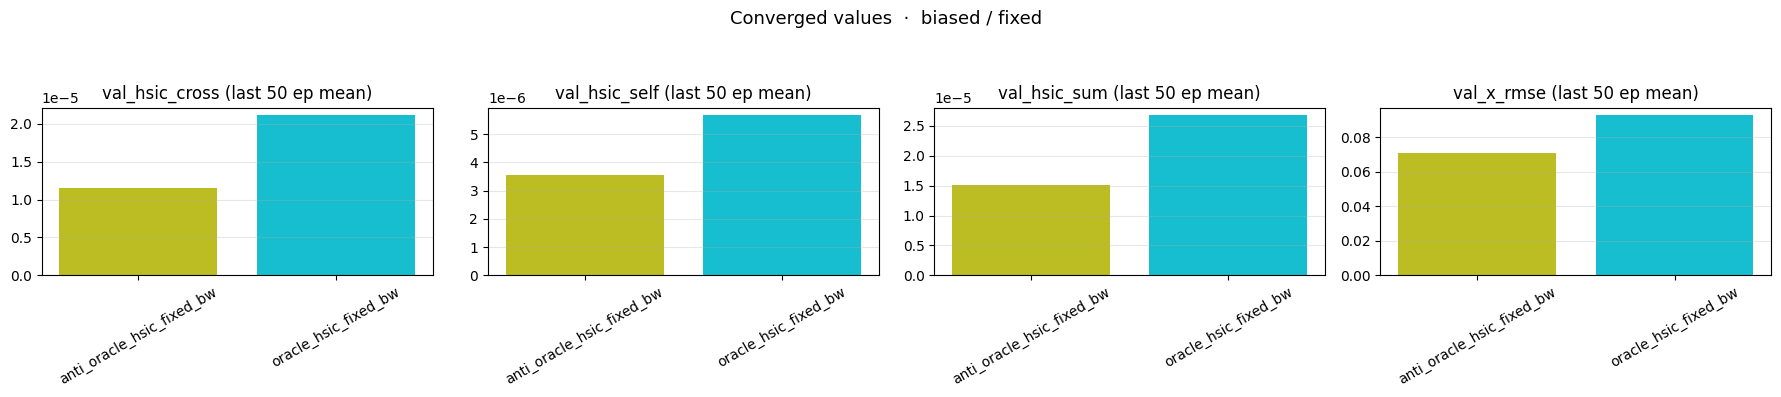


=== normalized / adaptive   (2 runs) ===


,val_hsic_cross,val_hsic_self,val_hsic_sum,val_x_rmse,val_x_mae,val_x_r2
label,,,,,,
hsic_norm,0.1911,0.1873,0.3784,0.0926,0.0736,0.5752
hsic_norm_random_oracle,0.1961,0.2247,0.4208,0.1070,0.0871,0.4329


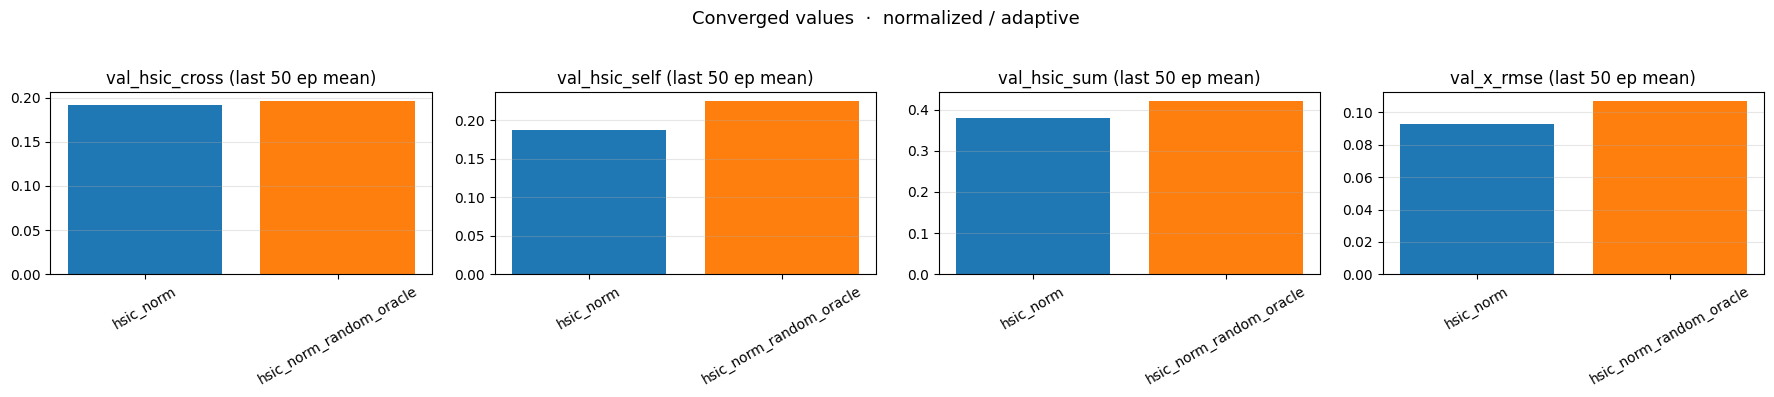


=== normalized / fixed   (2 runs) ===


,val_hsic_cross,val_hsic_self,val_hsic_sum,val_x_rmse,val_x_mae,val_x_r2
label,,,,,,
anti_oracle_nhsic_fixed_bw,0.0163,0.0139,0.0302,0.0951,0.0739,0.5521
oracle_nhsic_fixed_bw,0.0217,0.0141,0.0358,0.0929,0.0738,0.5731


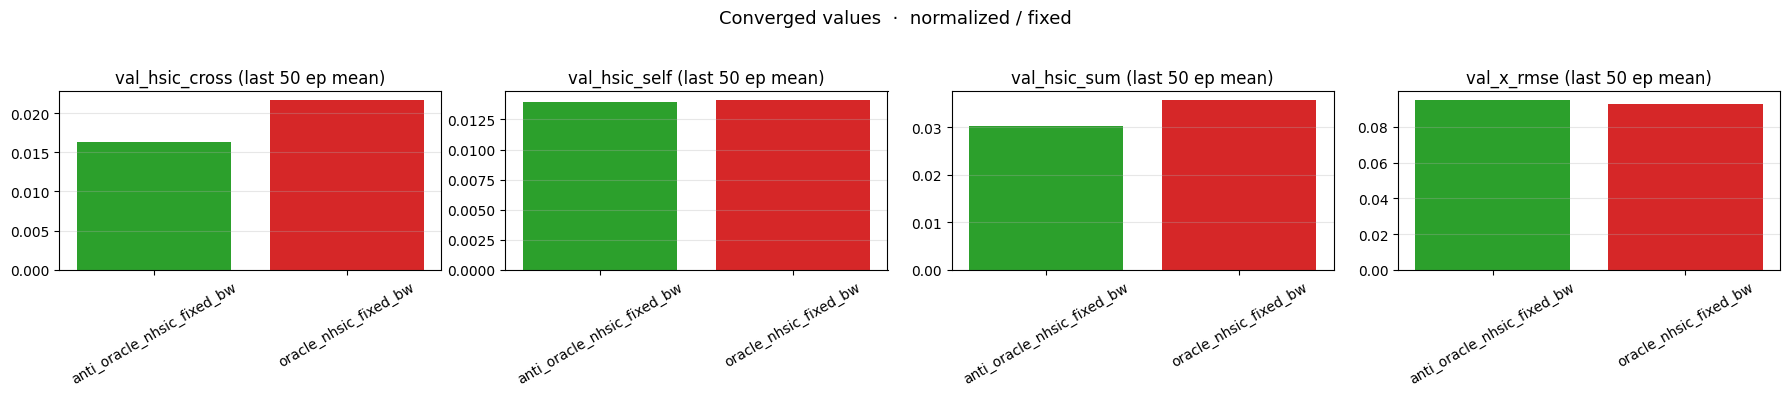

In [118]:
_CONV_METRICS = [
    "val_hsic_cross", "val_hsic_self", "val_hsic_sum", "val_x_rmse", "val_x_mae", "val_x_r2",
]
_BAR_METRICS = ["val_hsic_cross", "val_hsic_self", "val_hsic_sum", "val_x_rmse"]

def _converged_table(runs_dict: dict) -> pd.DataFrame:
    rows = []
    for label, item in runs_dict.items():
        df = item["df"]
        last_epochs = df.tail(CONVERGED_WINDOW)
        row = {"label": label}
        for m in _CONV_METRICS:
            row[m] = float(last_epochs[m].mean(skipna=True)) if m in last_epochs.columns else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("label") if rows else pd.DataFrame(columns=_CONV_METRICS)

for mode, runs_g in split_runs_by_hsic_mode(runs).items():
    print(f"\n=== {mode}   ({len(runs_g)} runs) ===")
    conv = _converged_table(runs_g)
    display(conv.style.format("{:.4f}"))

    fig, axes = plt.subplots(1, len(_BAR_METRICS), figsize=(4.5 * len(_BAR_METRICS), 4))
    for ax, m in zip(axes, _BAR_METRICS):
        series = conv[m].dropna() if m in conv.columns else pd.Series(dtype=float)
        if series.empty:
            ax.text(0.5, 0.5, f"no '{m}' logged", ha="center", va="center",
                    transform=ax.transAxes, alpha=0.5)
        else:
            colors = [color_for(lbl) for lbl in series.index]
            ax.bar(series.index, series.values, color=colors)
        ax.set_title(f"{m} (last {CONVERGED_WINDOW} ep mean)")
        ax.tick_params(axis="x", rotation=30)
        ax.grid(True, axis="y", alpha=0.3)
    fig.suptitle(f"Converged values  ·  {mode}", fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

### Reading the bars

- `val_hsic_cross[hsic_bias]` ≈ **floor** for biased HSIC.
- `val_hsic_cross[random_oracle]` ≈ **ceiling** (a confidently wrong DAG).
- `val_x_rmse[small_capacity]` should rise relative to the others — confirming
  that reconstruction (not HSIC) is what suffers when capacity is reduced.
- Once `hsic_norm` and `small_batch` runs land, they appear automatically:
  - `hsic_norm` becomes the floor for the **normalised** HSIC estimator.
  - `small_batch` separates O(1/B) finite-sample HSIC bias from data-bound floor.